In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("data.csv", encoding='ISO-8859-1', parse_dates=['InvoiceDate'])

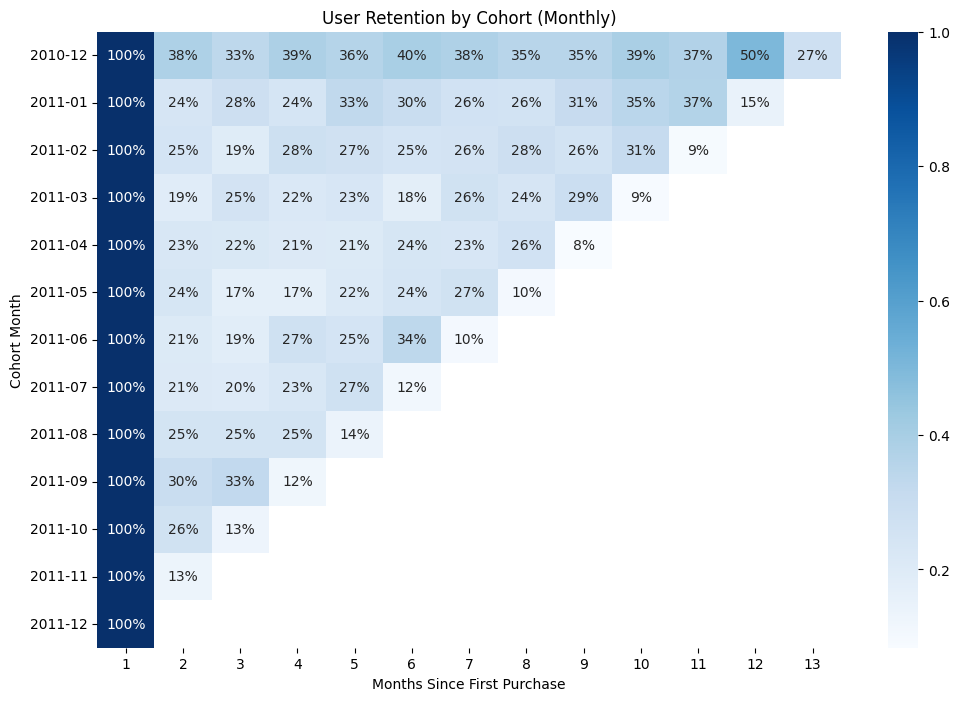

In [3]:
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# Keep only relevant columns: Customer ID and Invoice Date
df = df[['CustomerID', 'InvoiceDate']].dropna()

# Create cohort month (year-month of first purchase)
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'] \
                     .transform('min') \
                     .dt.to_period('M')

# Extract the transaction month
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# Compute period number: number of months since cohort
cohort_data = df.groupby(['CohortMonth', 'InvoiceMonth']) \
                .agg(n_customers=('CustomerID', 'nunique')) \
                .reset_index()

cohort_data['CohortIndex'] = (cohort_data['InvoiceMonth'].dt.year - cohort_data['CohortMonth'].dt.year) * 12 + \
                             (cohort_data['InvoiceMonth'].dt.month - cohort_data['CohortMonth'].dt.month) + 1

# Pivot the data: rows = CohortMonth, columns = CohortIndex
cohort_pivot = cohort_data.pivot(index='CohortMonth',
                                 columns='CohortIndex',
                                 values='n_customers')

# Calculate retention rate by dividing each row by its first column value
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)

# Plot retention heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='Blues')
plt.title('User Retention by Cohort (Monthly)')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.show()

## Key Findings from the Cohort Retention Heatmap

1. **Rapid Early Churn**  
   - Between Month 1 and Month 2, retention drops sharply: only 20–40% of each cohort return for a second purchase.  
   - **Implication:** The window immediately after a user’s first purchase is critical. Implement welcome email sequences, personalized offers, and onboarding guides to reduce early churn.

2. **Stabilized Retention Over Time**  
   - After the initial drop, retention rates level out around 15–30% for Months 3–6.  
   - **Implication:** Users who survive the initial churn are more likely to stick around. Introduce loyalty programs, subscriptions, or VIP perks to deepen engagement with these “survivor” users.

3. **Retention Spikes Indicate Effective Campaigns**  
   - Certain cohorts show localized upticks—for example, increased retention in Month 4 for the 2011-02 cohort.  
   - **Implication:** These spikes likely correspond to successful marketing campaigns or seasonal promotions. Investigate which tactics drove these gains and replicate them across other cohorts.

4. **Long-Term Decline for Early Cohorts**  
   - The earliest cohorts (e.g., 2010-12 through 2011-03) fall below 10% retention by Month 8–9.  
   - **Implication:** While some decline is inevitable, compare against more recent cohorts to measure product and marketing improvements over time.

5. **Opportunities for Re-Engagement**  
   - Noticeable bumps in retention around Months 5–8 suggest that re-engagement efforts (email blasts, feature updates) can revive interest even six months after signup.  
   - **Implication:** Schedule targeted re-engagement campaigns around 4–6 months to boost long-term retention.

## Recommendations

- **Optimize the Month 2–3 Window**  
  Deploy a structured follow-up cadence (welcome series, targeted offers) immediately after the first purchase to minimize early churn.

- **Analyze and Scale Successful Campaigns**  
  Perform a detailed post-mortem on retention “spikes” to identify the most effective marketing or product tactics, then roll them out to other segments.

- **Implement Loyalty and Subscription Programs**  
  Offer ongoing incentives—points, tiered rewards, or subscription benefits—to users who remain active past Month 3 or 4, increasing their lifetime value (LTV).

- **Segmented Engagement Strategies**  
  Break down cohorts by acquisition channel (e.g., email, organic, social) and device type (mobile vs. desktop) to tailor communication and promotions for maximum impact.

- **Schedule Mid-Term Re-Engagement**  
  Plan automated re-engagement campaigns (e.g., email reminders, new feature announcements) around the 5–8 month mark, when users are most likely receptive to returning.

